<a href="https://colab.research.google.com/github/bugindacodeQ/PINN_KK_RELATIONS/blob/main/PINN_KK_RELATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install numpy matplotlib torch --quiet

Training PINN...
Epoch    0 | Total Loss: 1.744826e+00


/tmp/ipykernel_11798/1021090287.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  kk_pred[j] = (2.0 / np.pi) * np.trapz(integrand, om)


Epoch  300 | Total Loss: 2.010137e+00
Epoch  600 | Total Loss: 5.338044e-01
Epoch  900 | Total Loss: 1.040228e-01


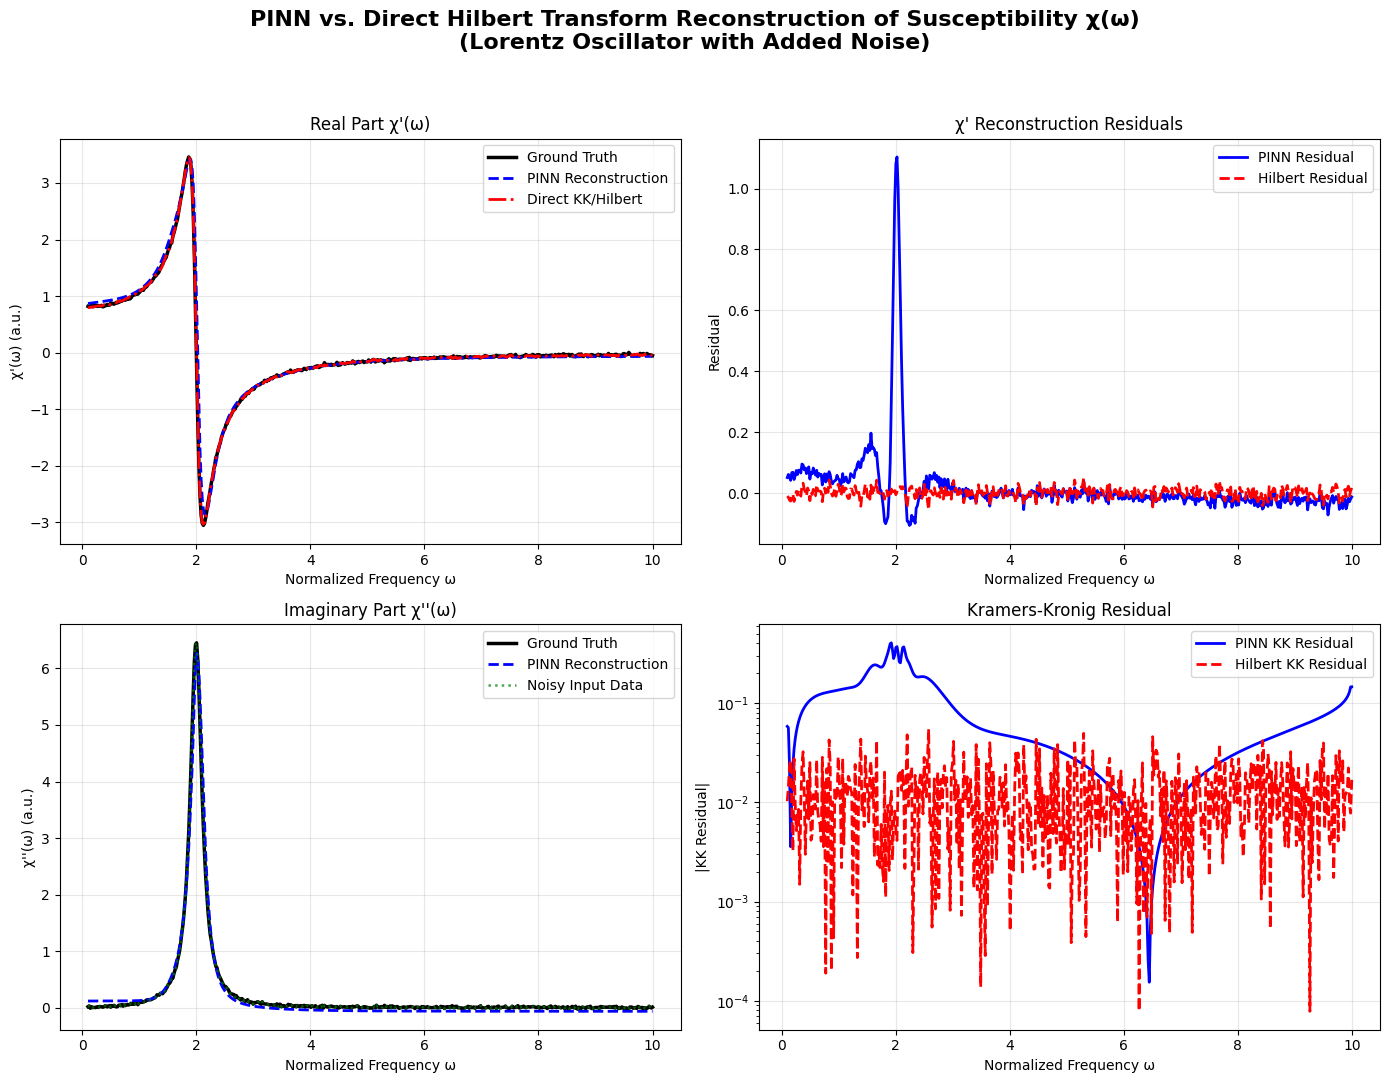

Four-panel figure generated successfully!


In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# =============================================================================
# 1. Lorentz Oscillator + Synthetic Data Generation
# =============================================================================
def lorentz_oscillator(omega, omega0=2.0, gamma=0.25, omega_p=1.8):
    """Single Lorentz oscillator susceptibility χ(ω)"""
    denom = omega0**2 - omega**2 - 1j * gamma * omega
    return omega_p**2 / denom


def generate_synthetic_data(omega_min=0.1, omega_max=10.0, num_points=500, noise_level=0.015, seed=42):
    """Generate noisy χ'(ω) and χ''(ω) from Lorentz oscillator"""
    np.random.seed(seed)
    omega = np.linspace(omega_min, omega_max, num_points)

    chi_complex = lorentz_oscillator(omega)
    chi_real = np.real(chi_complex)
    chi_imag = np.imag(chi_complex)

    # Add Gaussian noise
    noise_r = np.random.normal(0, noise_level * np.std(chi_real), num_points)
    noise_i = np.random.normal(0, noise_level * np.std(chi_imag), num_points)

    return omega, chi_real + noise_r, chi_imag + noise_i


# =============================================================================
# 2. PINN Model (KKNet)
# =============================================================================
class KKNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 2)          # outputs: χ'(ω), χ''(ω)
        )

    def forward(self, omega):
        if omega.dim() == 1:
            omega = omega.unsqueeze(1)
        out = self.net(omega)
        return out[:, 0], out[:, 1]


# =============================================================================
# 3. Numerical KK Integral (Cauchy principal value)
# =============================================================================
def kk_integral(chi_imag, omega, epsilon=1e-4):
    """Compute χ'_KK(ω) from χ''(ω) using trapezoidal rule with singularity exclusion"""
    N = len(omega)
    kk_pred = np.zeros(N)
    for j in range(N):
        w = omega[j]
        mask = np.abs(omega - w) > epsilon
        om = omega[mask]
        ch = chi_imag[mask]
        if len(om) < 2:
            continue
        integrand = (om * ch) / (om**2 - w**2)
        kk_pred[j] = (2.0 / np.pi) * np.trapz(integrand, om)
    return kk_pred


# =============================================================================
# 4. Main: Generate data, train PINN, and create 4-panel figure
# =============================================================================
if __name__ == "__main__":
    # Generate synthetic data
    omega, chi_real_gt, chi_imag_gt = generate_synthetic_data()

    # Convert to torch tensors
    device = torch.device("cpu")
    omega_t = torch.tensor(omega, dtype=torch.float32, device=device).unsqueeze(1)
    chi_real_t = torch.tensor(chi_real_gt, dtype=torch.float32, device=device)
    chi_imag_t = torch.tensor(chi_imag_gt, dtype=torch.float32, device=device)

    # Initialize model and optimizer
    model = KKNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    lambda_phys = 8.0          # Physics loss weight
    epochs = 1200

    print("Training PINN...")
    for epoch in range(epochs):
        optimizer.zero_grad()

        chi_prime_pred, chi_imag_pred = model(omega_t)

        # Data loss
        data_loss = torch.mean((chi_prime_pred - chi_real_t)**2 +
                               (chi_imag_pred - chi_imag_t)**2)

        # Physics (KK) loss
        chi_imag_np = chi_imag_pred.detach().cpu().numpy()
        kk_prime = kk_integral(chi_imag_np, omega)
        kk_prime_t = torch.tensor(kk_prime, dtype=torch.float32, device=device)
        phys_loss = torch.mean((chi_prime_pred - kk_prime_t)**2)

        total_loss = data_loss + lambda_phys * phys_loss
        total_loss.backward()
        optimizer.step()

        if epoch % 300 == 0:
            print(f"Epoch {epoch:4d} | Total Loss: {total_loss.item():.6e}")

    # Get final predictions
    with torch.no_grad():
        chi_prime_pinn, chi_imag_pinn = model(omega_t)
        chi_prime_pinn = chi_prime_pinn.cpu().numpy()
        chi_imag_pinn = chi_imag_pinn.cpu().numpy()

    # Direct KK reconstruction from noisy imaginary part
    kk_direct = kk_integral(chi_imag_gt, omega)

    # =============================================================================
    # 5. Create the Four-Panel Figure
    # =============================================================================
    fig, axs = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle('PINN vs. Direct Hilbert Transform Reconstruction of Susceptibility χ(ω)\n'
                 '(Lorentz Oscillator with Added Noise)', fontsize=16, fontweight='bold')

    # Top-left: χ'(ω) comparison
    axs[0,0].plot(omega, chi_real_gt, 'k-', lw=2.5, label='Ground Truth')
    axs[0,0].plot(omega, chi_prime_pinn, 'b--', lw=2, label='PINN Reconstruction')
    axs[0,0].plot(omega, kk_direct, 'r-.', lw=2, label='Direct KK/Hilbert')
    axs[0,0].set_xlabel('Normalized Frequency ω')
    axs[0,0].set_ylabel("χ'(ω) (a.u.)")
    axs[0,0].set_title('Real Part χ\'(ω)')
    axs[0,0].legend()
    axs[0,0].grid(alpha=0.3)

    # Top-right: χ' residuals
    axs[0,1].plot(omega, chi_prime_pinn - chi_real_gt, 'b-', lw=2, label='PINN Residual')
    axs[0,1].plot(omega, kk_direct - chi_real_gt, 'r--', lw=2, label='Hilbert Residual')
    axs[0,1].set_xlabel('Normalized Frequency ω')
    axs[0,1].set_ylabel('Residual')
    axs[0,1].set_title('χ\' Reconstruction Residuals')
    axs[0,1].legend()
    axs[0,1].grid(alpha=0.3)

    # Bottom-left: χ''(ω) comparison
    axs[1,0].plot(omega, chi_imag_gt, 'k-', lw=2.5, label='Ground Truth')
    axs[1,0].plot(omega, chi_imag_pinn, 'b--', lw=2, label='PINN Reconstruction')
    axs[1,0].plot(omega, chi_imag_gt, 'g:', lw=1.8, alpha=0.7, label='Noisy Input Data')
    axs[1,0].set_xlabel('Normalized Frequency ω')
    axs[1,0].set_ylabel("χ''(ω) (a.u.)")
    axs[1,0].set_title('Imaginary Part χ\'\'(ω)')
    axs[1,0].legend()
    axs[1,0].grid(alpha=0.3)

    # Bottom-right: KK residual
    kk_pinn_residual = np.abs(chi_prime_pinn - kk_integral(chi_imag_pinn, omega))
    axs[1,1].plot(omega, kk_pinn_residual, 'b-', lw=2, label='PINN KK Residual')
    axs[1,1].plot(omega, np.abs(chi_real_gt - kk_direct), 'r--', lw=2, label='Hilbert KK Residual')
    axs[1,1].set_xlabel('Normalized Frequency ω')
    axs[1,1].set_ylabel('|KK Residual|')
    axs[1,1].set_title('Kramers-Kronig Residual')
    axs[1,1].set_yscale('log')
    axs[1,1].legend()
    axs[1,1].grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    print("Four-panel figure generated successfully!")